In [2]:
%run shared_imports.py

In [3]:
engine = make_engine("settings.toml")
session = Session(engine)

In [4]:
query = select(Feedback.json, Feedback.datetime).filter(
    Feedback.key_name == 'job_preferences',
    Feedback.datetime >= datetime(2023, 7, 1))

In [5]:
df = pd.read_sql_query(query, session.connection())

In [6]:
def job_preferences(jobname):
    return lambda x: {pref: count for pref, count in x['data'][jobname].items() if pref in ('high', 'medium', 'low', 'never')}

In [7]:
df = df.join(pd.json_normalize(df.json.map(job_preferences('Captain')))).drop(['json'], axis=1)
df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
df.drop(['datetime'], inplace=True, axis=1)

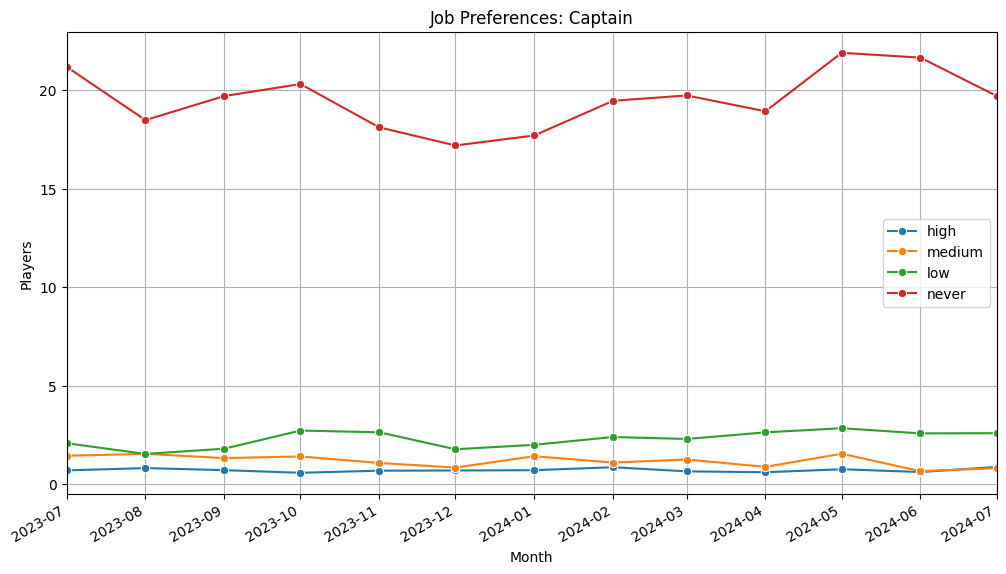

In [17]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=df.groupby(['dt']).mean(),
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2023, 7, 1), date(2024, 7, 1)))
plot.set(title='Job Preferences: Captain')
plot.set(xlabel='Month', ylabel='Players')
months = mdates.MonthLocator(interval=1) 
ax.xaxis.set_major_locator(months)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()
